# Notebook 1: Preprocesamiento y Detección de Data Leakage
## Proyecto Integrador — Predicción de Falla Cardíaca

**Objetivo:** Demostrar el impacto del data leakage en el rendimiento del modelo y construir un flujo correcto usando `Pipeline` y `GridSearchCV`.

**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga y Exploración del Dataset

In [2]:
df = pd.read_csv("../heart.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,58,M,ASY,122,27,0,LVH,65,Y,0.0,Flat,1
1,52,F,NAP,101,361,0,LVH,169,N,0.8,Flat,0
2,59,M,ATA,111,162,0,LVH,155,Y,0.2,Flat,1
3,67,M,ASY,154,174,1,Normal,92,N,0.3,Up,1
4,51,M,ATA,129,129,0,Normal,120,Y,1.2,Flat,0
5,51,M,ATA,122,166,0,ST,175,N,0.3,Up,0
6,68,M,ASY,134,352,0,ST,172,N,0.2,Up,1
7,60,M,TA,141,0,0,ST,159,Y,0.1,Up,1
8,49,M,ASY,152,337,0,Normal,131,Y,1.2,Flat,1
9,58,M,ASY,158,234,0,LVH,138,N,0.1,Flat,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.7 KB


In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.708061,131.407407,196.753813,0.228758,134.252723,0.765795,0.590414
std,8.735028,17.929634,107.489212,0.420262,25.506288,0.768722,0.492025
min,28.000000,78.000000,0.000000,0.000000,63.000000,0.000000,0.000000
25%,48.000000,119.000000,119.000000,0.000000,116.250000,0.200000,0.000000
50%,54.000000,131.000000,194.000000,0.000000,134.000000,0.500000,1.000000
75%,59.000000,144.000000,262.000000,0.000000,152.000000,1.100000,1.000000
max,77.000000,200.000000,551.000000,1.000000,202.000000,6.100000,1.000000


HeartDisease
1    542
0    376
Name: count, dtype: int64

Proporción clase positiva: 59.04%


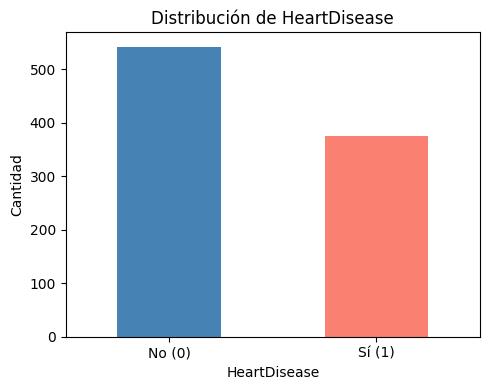

In [5]:
# Distribución de la variable objetivo
print(df['HeartDisease'].value_counts())
print(f"\nProporción clase positiva: {df['HeartDisease'].mean():.2%}")

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
df['HeartDisease'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
ax.set_title("Distribución de HeartDisease")
ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.show()

## 2. Análisis Exploratorio (EDA)

In [6]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total nulos: 0


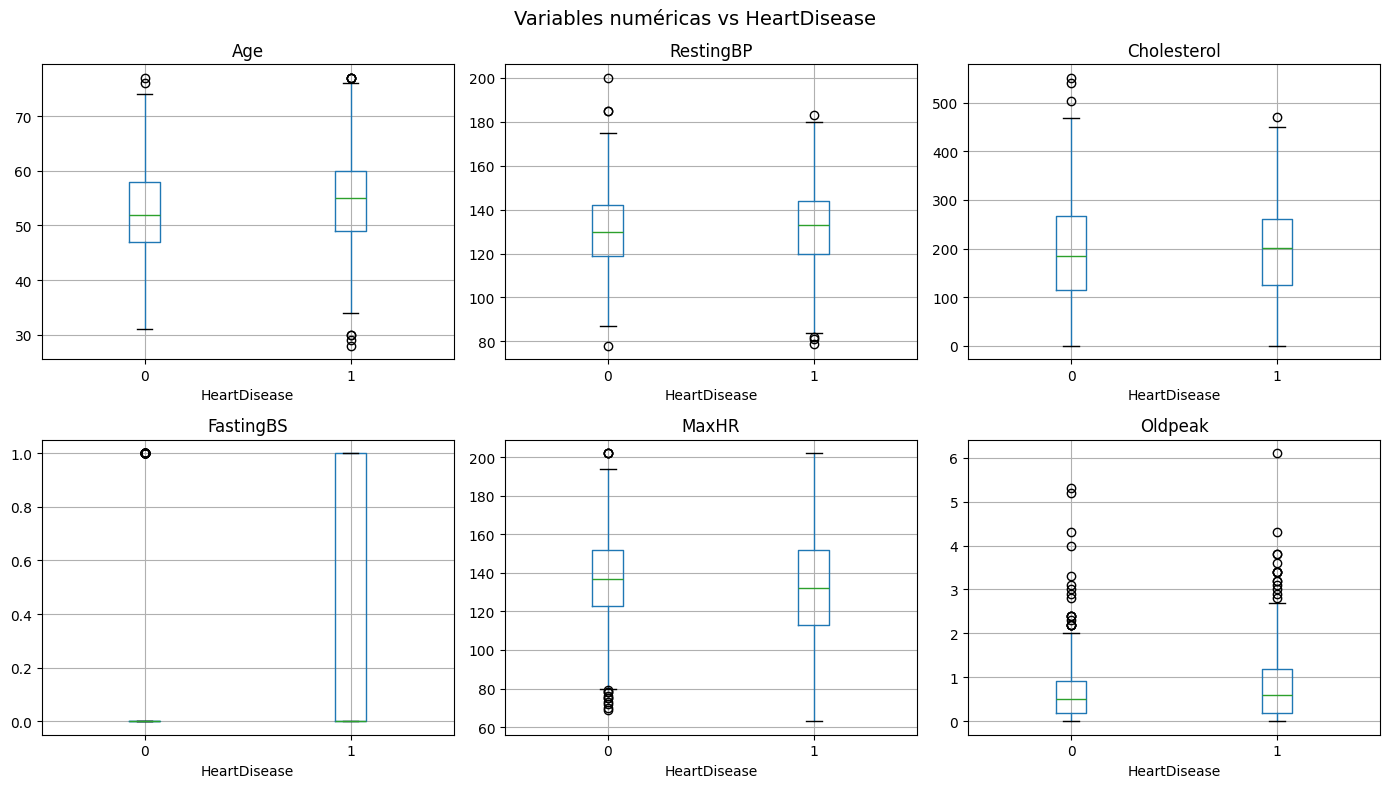

In [7]:
# Variables numéricas vs HeartDisease
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('HeartDisease')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    df.boxplot(column=col, by='HeartDisease', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('HeartDisease')
plt.suptitle("Variables numéricas vs HeartDisease", fontsize=14)
plt.tight_layout()
plt.show()

Variables categóricas: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


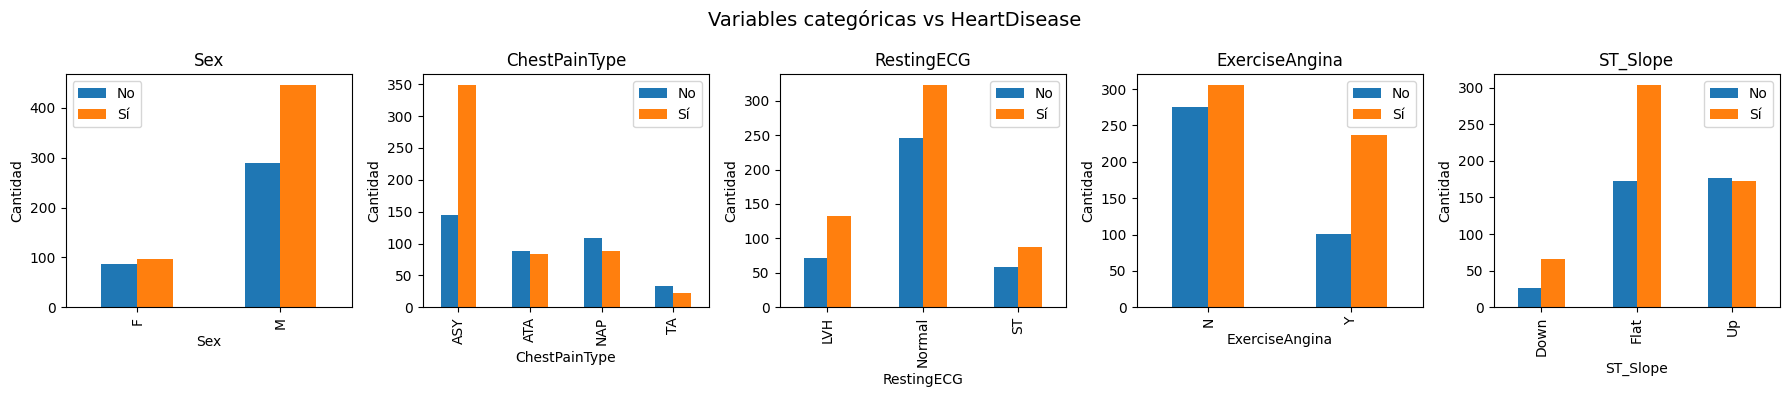

In [8]:
# Variables categóricas vs HeartDisease
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Variables categóricas:", cat_cols)

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for i, col in enumerate(cat_cols):
    pd.crosstab(df[col], df['HeartDisease']).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Cantidad")
    axes[i].legend(['No', 'Sí'])
plt.suptitle("Variables categóricas vs HeartDisease", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

In [9]:
# Separar features y target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Codificar variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Features después de encoding: {X_encoded.shape[1]} columnas")
print(X_encoded.columns.tolist())

Features después de encoding: 15 columnas
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


## 4. Demostración de Data Leakage

### 4.1 Flujo INCORRECTO — con fuga de datos

Se introduce una variable artificial que filtra información del target. Además, se escala **todo el dataset** antes de dividir, lo cual permite que información del test se filtre al entrenamiento.

In [10]:
# === FLUJO CON DATA LEAKAGE ===

# Variable artificial que introduce fuga
X_leak = X_encoded.copy()
np.random.seed(0)
X_leak["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

# ERROR 1: Escalar TODO antes de dividir
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_leak)

# ERROR 2: Dividir después de escalar
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# GridSearchCV sobre datos ya contaminados
grid_l = GridSearchCV(
    SVC(probability=True),
    param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
    cv=5, scoring="roc_auc"
)
grid_l.fit(X_train_l, y_train_l)

auc_l = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])
print(f"AUC CON data leakage: {auc_l:.3f}")
print(f"Mejores parámetros (con leakage): {grid_l.best_params_}")

AUC CON data leakage: 1.000
Mejores parámetros (con leakage): {'C': 0.1, 'gamma': 0.01}


### 4.2 Flujo CORRECTO — sin fuga de datos

1. Primero dividir los datos
2. Escalar solo con datos de entrenamiento usando `Pipeline`
3. Sin la variable leaky

In [11]:
# === FLUJO SIN DATA LEAKAGE (correcto) ===

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svc", SVC(probability=True))
])

param_grid = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
print(f"AUC SIN data leakage: {auc:.3f}")
print(f"Mejores parámetros (sin leakage): {grid.best_params_}")

AUC SIN data leakage: 0.740
Mejores parámetros (sin leakage): {'svc__C': 10, 'svc__gamma': 0.01}


### 4.3 Comparación de Resultados

AUC CON data leakage:  1.000  <- inflado artificialmente
AUC SIN data leakage:  0.740  <- resultado real

Conclusión: El data leakage infla el AUC artificialmente.
Usar Pipeline garantiza que el escalado se aplique solo
a los datos de entrenamiento dentro de la validación cruzada.


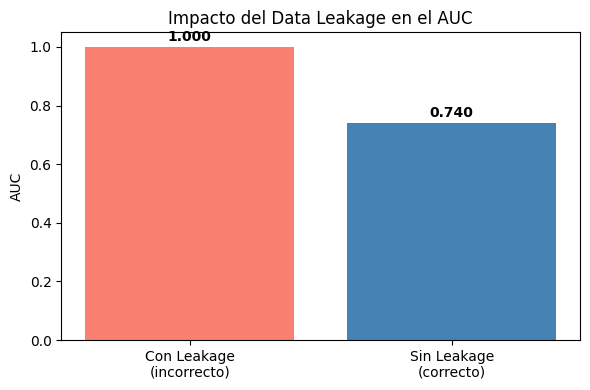

In [12]:
print("=" * 50)
print(f"AUC CON data leakage:  {auc_l:.3f}  <- inflado artificialmente")
print(f"AUC SIN data leakage:  {auc:.3f}  <- resultado real")
print("=" * 50)
print()
print("Conclusión: El data leakage infla el AUC artificialmente.")
print("Usar Pipeline garantiza que el escalado se aplique solo")
print("a los datos de entrenamiento dentro de la validación cruzada.")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Con Leakage\n(incorrecto)", "Sin Leakage\n(correcto)"],
              [auc_l, auc], color=["salmon", "steelblue"])
ax.set_ylabel("AUC")
ax.set_title("Impacto del Data Leakage en el AUC")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, [auc_l, auc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()